In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('cleaned_data.csv')

1. Understand the dataset
2. Find missing values
3. Detect duplicates
4. Identify outliers
5. Understand relationships
6. Check data distribution
7. Find errors and inconsistencies
8. Select useful features
9. Improve model performance

1. company - wise count
2. year - wise count
3. fuel - type count
4. min, max, avg of kms_driven (consider kms above 1000)
5. kms_driven wise company
6. price - wise vehicle
7. year - wise price

In [3]:
df = df[(df['kms_driven'] >1000) & (df['kms_driven'] < 200000)]     # 1000 - 200000
# price = 70,000 / 7,000 - 20,00,000


In [4]:
df = df[(df['Price'] >7000) & (df['Price'] < 2000000)]

In [5]:
df

,Unnamed: 0,name,company,year,Price,kms_driven,fuel_type
0,0,SantroXing,Hyundai,2007,80000,45000,Petrol
2,3,Grandi10,Hyundai,2014,325000,28000,Petrol
3,4,EcoSportTitanium,Ford,2014,575000,36000,Diesel
4,6,Figo,Ford,2012,175000,41000,Diesel
5,7,Eon,Hyundai,2013,190000,25000,Petrol
...,...,...,...,...,...,...,...
715,883,SuzukiRitz,Maruti,2011,270000,50000,Petrol
716,885,IndicaV2,Tata,2009,110000,30000,Diesel
717,886,CorollaAltis,Toyota,2009,300000,132000,Petrol
718,888,ZestXM,Tata,2018,260000,27000,Diesel


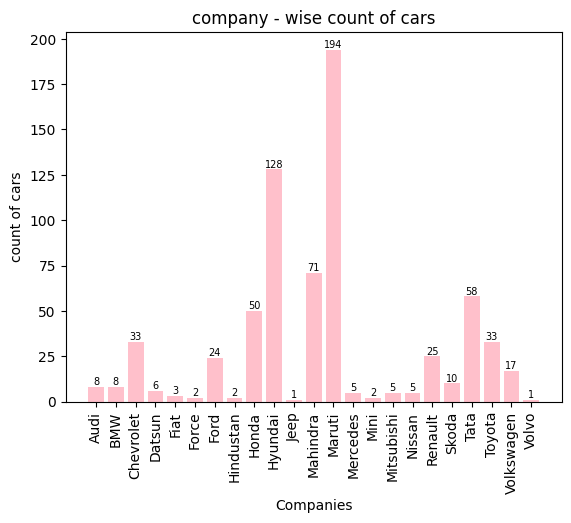

<Figure size 1000x500 with 0 Axes>

In [6]:
# company wise count
data = df['company'].value_counts().sort_index()
plt.bar(data.index, data.values, color = 'pink')
plt.xticks(rotation = 90)
plt.xlabel('Companies')
plt.ylabel('count of cars')
plt.title('company - wise count of cars')
for x,y in zip (data.index, data.values):
    plt.text(x, y, y, ha = 'center', va = 'bottom', fontsize = 7)
plt.figure(figsize = (10,5))
plt.show()

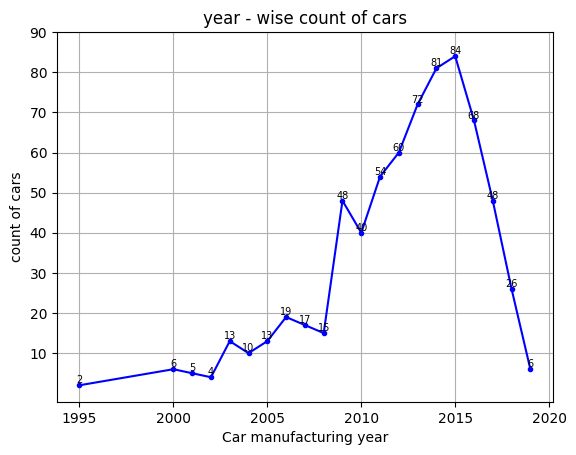

<Figure size 1000x500 with 0 Axes>

In [7]:
# year wise count

year = df['year'].value_counts().sort_index()
plt.plot(year.index, year.values, color = 'blue', marker = 'o', markersize = 3)
plt.xlabel('Car manufacturing year')
plt.ylabel('count of cars')
plt.yticks([10,20,30,40,50,60,70,80,90])
plt.grid(True)
plt.title('year - wise count of cars')
for x,y in zip (year.index, year.values):
    plt.text(x, y, y, ha = 'center',va = 'bottom', fontsize = 7)
plt.figure(figsize = (10,5))
plt.show()


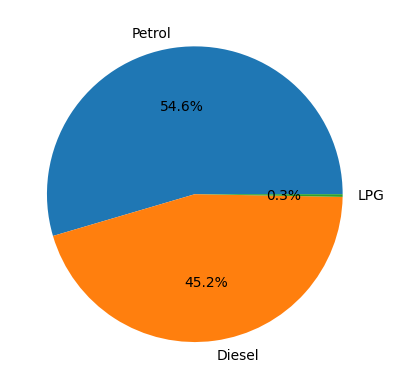

In [8]:
# fuel - type count
fuel = df['fuel_type'].value_counts()
plt.pie(fuel.values, labels = fuel.index, autopct = '%1.1f%%', startangle = 0, explode = [0.0, 0.0,0.0])
plt.show()


In [9]:
# min, max, avg of kms_driven (consider kms above 1000)
minm = df['kms_driven'].min()
maxm = df['kms_driven'].max()
avg = df['kms_driven'].mean()
print('Least kms driven car:',minm)
print('Most kms driven car:',maxm)
print('Avg kms driven car:',round(avg))

Least kms driven car: 1500
Most kms driven car: 195000
Avg kms driven car: 47026


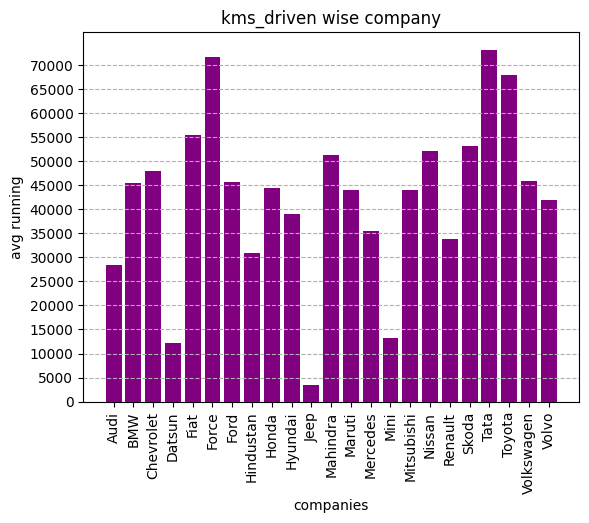

<Figure size 10000x30000 with 0 Axes>

In [10]:
# groupby() used to categorise data in particular column and perform calculation in each category seperately
data = df.groupby('company')['kms_driven'].mean()

# avg kms_driven wise company
plt.bar(data.index, data.values, color = 'purple')
plt.title('kms_driven wise company')
plt.xlabel('companies')
plt.yticks(np.arange(0,75000,5000))
plt.grid(axis = 'y', linestyle = '--')
plt.ylabel('avg running')
plt.xticks(rotation = 90)
plt.figure(figsize = (100, 300))
plt.show()



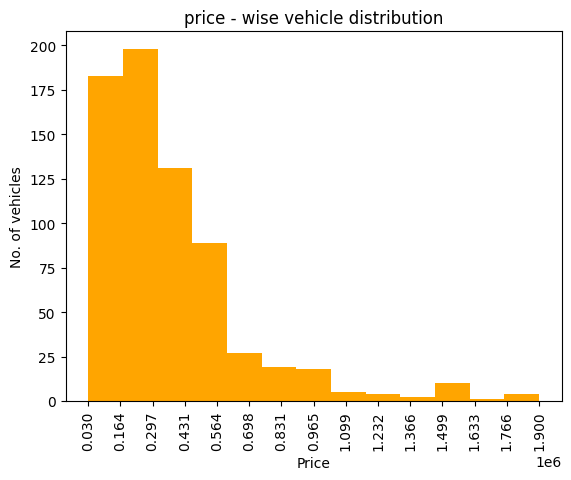

In [11]:
# price - wise vehicle
plt.hist(df['Price'], bins = 13, color = 'orange')
plt.xlabel('Price')
plt.ylabel('No. of vehicles')
plt.title('price - wise vehicle distribution')
plt.xticks(np.arange(30000, 1900000, 133571))
plt.xticks(rotation = 90)

plt.show()

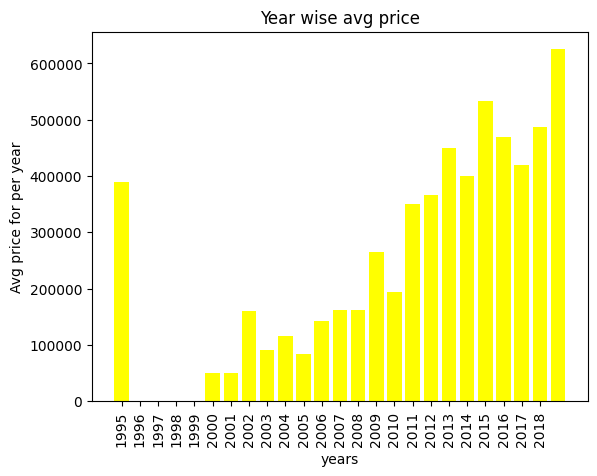

In [12]:
# year wise price
data = df.groupby('year')['Price'].mean()
plt.bar(data.index, data.values, color = 'yellow')
plt.xlabel('years')
plt.ylabel('Avg price for per year')
plt.title('Year wise avg price')
plt.xticks(np.arange(1995,2019,1))
plt.xticks(rotation = 90)
plt.show()


In [16]:
df.info()


<class 'pandas.DataFrame'>
Index: 691 entries, 0 to 719
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  691 non-null    int64
 1   name        691 non-null    str  
 2   company     691 non-null    str  
 3   year        691 non-null    int64
 4   Price       691 non-null    int64
 5   kms_driven  691 non-null    int64
 6   fuel_type   691 non-null    str  
dtypes: int64(4), str(3)
memory usage: 43.2 KB


,Unnamed: 0,name,company,year,Price,kms_driven,fuel_type
0,0,SantroXing,Hyundai,2007,80000,45000,Petrol
1,3,Grandi10,Hyundai,2014,325000,28000,Petrol
2,4,EcoSportTitanium,Ford,2014,575000,36000,Diesel
3,6,Figo,Ford,2012,175000,41000,Diesel
4,7,Eon,Hyundai,2013,190000,25000,Petrol
...,...,...,...,...,...,...,...
686,883,SuzukiRitz,Maruti,2011,270000,50000,Petrol
687,885,IndicaV2,Tata,2009,110000,30000,Diesel
688,886,CorollaAltis,Toyota,2009,300000,132000,Petrol
689,888,ZestXM,Tata,2018,260000,27000,Diesel


,Unnamed: 0,name,company,year,Price,kms_driven,fuel_type
0,0,SantroXing,Hyundai,2007,80000,45000,Petrol
1,3,Grandi10,Hyundai,2014,325000,28000,Petrol
2,4,EcoSportTitanium,Ford,2014,575000,36000,Diesel
3,6,Figo,Ford,2012,175000,41000,Diesel
4,7,Eon,Hyundai,2013,190000,25000,Petrol
...,...,...,...,...,...,...,...
686,883,SuzukiRitz,Maruti,2011,270000,50000,Petrol
687,885,IndicaV2,Tata,2009,110000,30000,Diesel
688,886,CorollaAltis,Toyota,2009,300000,132000,Petrol
689,888,ZestXM,Tata,2018,260000,27000,Diesel


In [18]:
df.to_csv('final_data.csv', index = False)